# Comprehensive Road Scene Understanding for Autonomous Driving
**Anomaly Segmentation with Pixel-based (ERFNet) and Mask-based (EoMT) models.**

This notebook reproduces every experiment of the project:
- **Step 7** — ERFNet pixel-based anomaly baselines (MSP, MaxLogit, MaxEntropy)
- **Step 8** — EoMT mask-based baselines (+ RbA) for the Cityscapes, COCO and fine-tuned checkpoints, plus temperature scaling
- **Step 4** — closed-set mIoU comparison (COCO vs Cityscapes EoMT)
- **Step 5** — fine-tuning the COCO model on Cityscapes

**Before running:** set the Colab runtime to a **GPU** (Runtime → Change runtime type → T4). The Cityscapes download (Step 4) needs a free **Kaggle API token**.

## 0. Environment & Setup
Check that a GPU is attached.

In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE")

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


Clone the course repository (ERFNet code, EoMT code, pretrained ERFNet weights).

In [2]:
%cd /content
!git clone -q https://github.com/AlessandroMarinai/MaskArchitectureAnomaly_CourseProject.git
%cd MaskArchitectureAnomaly_CourseProject
!ls

/content
/content/MaskArchitectureAnomaly_CourseProject
eomt  eval  README.md  trained_models


Download the anomaly validation datasets (RoadAnomaly21, RoadObstacle21, FS Lost&Found, FS Static, RoadAnomaly) and the EoMT checkpoints from the course Drive folder, then unzip them.

In [3]:
!pip install -q gdown
!gdown --folder "https://drive.google.com/drive/folders/1q2vHUzora2nP52fP50zmoQAykWuwoGav" -O /content/datasets
import zipfile
with zipfile.ZipFile('/content/datasets/Anomaly_Validation_Datasets.zip') as z:
    z.extractall('/content/datasets/anomaly')
print("setup done")

Retrieving folder contents
Retrieving folder 11uyQc6M8xDTGji1bltehx0wlylqA4isf Project Descriptions
Processing file 1tq5F_j_8O2vlGWbkU1ayPjYvCml1VEwr ComprehensiveRoadScenesUnderstanding.pdf
Processing file 1Vz08DHsP_mojpCTAQTR6NHVq-2rEqAZM MaskArchitectureAnomalySegmentation.pdf
Processing file 1zcayoIIJztxKuHOIjmSjGoQBDy4RdETr Anomaly_Validation_Datasets.zip
Processing file 1vSLNXzu3zCuJ7oeu_hSV7xVTJPUoXvH0 eomt_cityscapes.bin
Processing file 13tCjPYFBVf43hS9SqODsKqGeGx2TsgzS eomt_coco.bin
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1tq5F_j_8O2vlGWbkU1ayPjYvCml1VEwr
To: /content/datasets/Project Descriptions/ComprehensiveRoadScenesUnderstanding.pdf
100% 329k/329k [00:00<00:00, 119MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Vz08DHsP_mojpCTAQTR6NHVq-2rEqAZM
To: /content/datasets/Project Descriptions/MaskArchitectureAnomalySegmentation.pdf
100% 307k/307k [00:00

## Step 7 — ERFNet (pixel-based baselines)
Load the pretrained ERFNet (20 output classes = 19 Cityscapes classes + void). We strip the `module.` prefix left by `DataParallel` and copy the weights into a fresh model.

In [4]:
import sys, torch
sys.path.append('/content/MaskArchitectureAnomaly_CourseProject/eval')
from erfnet import ERFNet

NUM_CLASSES = 20
WEIGHTS = '/content/MaskArchitectureAnomaly_CourseProject/trained_models/erfnet_pretrained.pth'
model = ERFNet(NUM_CLASSES)

def load_my_state_dict(model, state_dict):
    own = model.state_dict()
    for name, param in state_dict.items():
        clean = name.replace('module.', '')      # strip DataParallel prefix
        if clean in own:
            own[clean].copy_(param)
    return model

state_dict = torch.load(WEIGHTS, map_location='cpu', weights_only=False)
model = load_my_state_dict(model, state_dict)
model = model.cuda().eval()
print("ERFNet loaded")

ERFNet loaded


**Helpers shared by all anomaly experiments.**
- `fpr_at_95_tpr`: false-positive rate at 95% true-positive rate.
- `anomaly_score`: the four post-hoc scoring rules. MSP = `1 - max softmax`; MaxLogit = `-max logit`; MaxEntropy = predictive entropy; RbA = `-sum of class scores` (mask models only).
- `load_gt`: loads an anomaly label mask; RoadAnomaly encodes anomalies as `2` (others use `1`), so we remap it. Pixels equal to `255` are ignored.

In [5]:
import numpy as np, glob, os, torch
import torch.nn.functional as F
from PIL import Image
from torchvision.transforms import Compose, Resize, ToTensor
from sklearn.metrics import average_precision_score, roc_curve

DATA_ROOT = '/content/datasets/anomaly/Validation_Dataset'
input_transform = Compose([Resize((512, 1024), Image.BILINEAR), ToTensor()])   # ERFNet input (H, W)

def fpr_at_95_tpr(scores, labels):
    fpr, tpr, _ = roc_curve(labels, scores)
    return float(fpr[tpr >= 0.95][0])

def anomaly_score(logits, method):
    logits = logits.squeeze(0)                       # (C, H, W)
    if method == 'msp':
        return 1.0 - F.softmax(logits, dim=0).max(dim=0).values
    elif method == 'maxlogit':
        return -logits.max(dim=0).values
    elif method == 'maxentropy':
        p, lp = F.softmax(logits, dim=0), F.log_softmax(logits, dim=0)
        return -(p * lp).sum(dim=0)
    elif method == 'rba':                            # rejected-by-all (mask models only)
        return -logits.sum(dim=0)
    raise ValueError(method)

def load_gt(label_path, dataset_name):
    g = np.array(Image.open(label_path).resize((1024, 512), Image.NEAREST))   # (W, H)
    if dataset_name == 'RoadAnomaly':                # this set marks anomalies with 2, not 1
        g = np.where(g == 2, 1, g)
    return g

Evaluate ERFNet on all five benchmarks. One forward pass per image, reused for the three post-hoc scores; report AuPRC and FPR95.

In [6]:
import pandas as pd
METHODS  = ['msp', 'maxlogit', 'maxentropy']
DATASETS = ['RoadAnomaly21', 'RoadObsticle21', 'FS_LostFound_full', 'fs_static', 'RoadAnomaly']
COLS = {'RoadAnomaly21':'RA-21', 'RoadObsticle21':'RO-21',
        'FS_LostFound_full':'FS L&F', 'fs_static':'FS Static', 'RoadAnomaly':'Road Anomaly'}

def evaluate_all(dataset_name, model, methods=METHODS):
    paths = sorted(glob.glob(os.path.join(DATA_ROOT, dataset_name, 'images', '*')))
    scores = {m: [] for m in methods}; labels = []
    for p in paths:
        x = input_transform(Image.open(p).convert('RGB')).unsqueeze(0).cuda()
        with torch.no_grad():
            logits = model(x)
        lp = os.path.splitext(p.replace('/images/', '/labels_masks/'))[0] + '.png'
        g = load_gt(lp, dataset_name); valid = (g == 0) | (g == 1)
        labels.append(g[valid])
        for m in methods:
            scores[m].append(anomaly_score(logits, m).cpu().numpy()[valid])
    labels = np.concatenate(labels); out = {}
    for m in methods:
        sc = np.concatenate(scores[m])
        out[m] = (average_precision_score(labels, sc) * 100, fpr_at_95_tpr(sc, labels) * 100)
    return out

results_erfnet = {}
for ds in DATASETS:
    results_erfnet[ds] = evaluate_all(ds, model)
    print("done:", ds)
rows = []
for m in METHODS:
    row = {'Method': m}
    for ds in DATASETS:
        a, f = results_erfnet[ds][m]
        row[f'{COLS[ds]} AuPRC'] = round(a, 2); row[f'{COLS[ds]} FPR95'] = round(f, 2)
    rows.append(row)
df_erfnet = pd.DataFrame(rows).set_index('Method')
df_erfnet.to_csv('/content/results_erfnet.csv')
df_erfnet

done: RoadAnomaly21
done: RoadObsticle21
done: FS_LostFound_full
done: fs_static
done: RoadAnomaly


,RA-21 AuPRC,RA-21 FPR95,RO-21 AuPRC,RO-21 FPR95,FS L&F AuPRC,FS L&F FPR95,FS Static AuPRC,FS Static FPR95,Road Anomaly AuPRC,Road Anomaly FPR95
Method,,,,,,,,,,
msp,29.08,62.57,2.71,65.30,1.73,50.60,5.03,40.93,12.42,82.59
maxlogit,38.29,59.37,4.63,48.47,3.28,45.47,6.27,39.68,15.58,73.28
maxentropy,30.95,62.68,3.05,65.96,2.56,50.17,5.89,40.65,12.67,82.76


## Step 8 — EoMT (mask-based baselines)
Install the EoMT dependencies (we keep Colab's torch/numpy to avoid conflicts).

In [7]:
!pip install -q timm==1.0.15 transformers==4.56.1 lightning==2.5.1.post0 \
    "jsonargparse[signatures]==4.38" fvcore==0.1.5.post20221221 pycocotools
print("installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 156.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.4/219.4 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Import the EoMT model classes.

In [8]:
import sys
%cd /content/MaskArchitectureAnomaly_CourseProject/eomt
sys.path.append('/content/MaskArchitectureAnomaly_CourseProject/eomt')
import yaml
from models.vit import ViT
from models.eomt import EoMT
print("imports OK")

/content/MaskArchitectureAnomaly_CourseProject/eomt
imports OK


`load_eomt` builds the DINOv2 ViT backbone + EoMT head from a config, then loads a checkpoint (stripping the `network.` prefix). EoMT's `forward` returns per-layer `(mask_logits, class_logits)`; we always use the last layer `[-1]`. Here we load the **Cityscapes** checkpoint (19 classes, 100 queries, 1024×1024 input).

In [9]:
def load_eomt(config_path, ckpt_path, num_classes, img_size, device='cuda'):
    with open(config_path) as f:
        cfg = yaml.safe_load(f)
    na = cfg['model']['init_args']['network']['init_args']
    encoder = ViT(img_size=img_size, backbone_name=na['encoder']['init_args']['backbone_name'])
    net = EoMT(encoder=encoder, num_classes=num_classes,
               num_q=na['num_q'], num_blocks=na['num_blocks'], masked_attn_enabled=False)
    sd = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    if any(k.startswith('network.') for k in sd):
        sd = {k[len('network.'):]: v for k, v in sd.items() if k.startswith('network.')}
    missing, unexpected = net.load_state_dict(sd, strict=False)
    print(f"missing={len(missing)}  unexpected={len(unexpected)}")
    return net.eval().to(device), na['num_q']

CFG_CITY  = 'configs/dinov2/cityscapes/semantic/eomt_base_640.yaml'
CKPT_CITY = '/content/datasets/eomt_cityscapes.bin'
eomt_city, _ = load_eomt(CFG_CITY, CKPT_CITY, num_classes=19, img_size=(1024, 1024))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

missing=0  unexpected=0


Mask outputs are collapsed into a per-pixel class score map `L = sum_q sigmoid(mask_q) * softmax(class_q)` (dropping the no-object class), which the same `anomaly_score` rules then consume. `evaluate_all_eomt` reuses one forward pass for all four scores; `in_size` is the model's native square input.

In [10]:
EOMT_METHODS = ['msp', 'maxlogit', 'maxentropy', 'rba']
OUT_HW = (512, 1024)   # evaluation resolution, identical to ERFNet for fairness

def evaluate_all_eomt(dataset_name, net, in_size, methods=EOMT_METHODS):
    tf = Compose([Resize(in_size, Image.BILINEAR), ToTensor()])
    paths = sorted(glob.glob(os.path.join(DATA_ROOT, dataset_name, 'images', '*')))
    scores = {m: [] for m in methods}; labels = []
    for p in paths:
        x = tf(Image.open(p).convert('RGB')).unsqueeze(0).cuda()
        with torch.no_grad(), torch.autocast('cuda', dtype=torch.float16):
            ml, cl = net(x)
        m = F.interpolate(ml[-1].float(), size=OUT_HW, mode='bilinear', align_corners=False)
        L = torch.einsum('bqhw,bqc->bchw', m.sigmoid(), cl[-1].float().softmax(-1)[..., :-1])
        lp = os.path.splitext(p.replace('/images/', '/labels_masks/'))[0] + '.png'
        g = load_gt(lp, dataset_name); valid = (g == 0) | (g == 1)
        labels.append(g[valid])
        for mm in methods:
            scores[mm].append(anomaly_score(L, mm).cpu().numpy()[valid])
    labels = np.concatenate(labels); out = {}
    for mm in methods:
        sc = np.concatenate(scores[mm])
        out[mm] = (average_precision_score(labels, sc) * 100, fpr_at_95_tpr(sc, labels) * 100)
    return out

Anomaly table for the **Cityscapes** EoMT checkpoint.

In [11]:
results_eomt_city = {}
for ds in DATASETS:
    results_eomt_city[ds] = evaluate_all_eomt(ds, eomt_city, in_size=(1024, 1024))
    print("done:", ds)
rows = []
for m in EOMT_METHODS:
    row = {'Method': m}
    for ds in DATASETS:
        a, f = results_eomt_city[ds][m]
        row[f'{COLS[ds]} AuPRC'] = round(a, 2); row[f'{COLS[ds]} FPR95'] = round(f, 2)
    rows.append(row)
df_eomt_city = pd.DataFrame(rows).set_index('Method')
df_eomt_city.to_csv('/content/results_eomt_cityscapes.csv')
df_eomt_city

done: RoadAnomaly21
done: RoadObsticle21
done: FS_LostFound_full
done: fs_static
done: RoadAnomaly


,RA-21 AuPRC,RA-21 FPR95,RO-21 AuPRC,RO-21 FPR95,FS L&F AuPRC,FS L&F FPR95,FS Static AuPRC,FS Static FPR95,Road Anomaly AuPRC,Road Anomaly FPR95
Method,,,,,,,,,,
msp,74.25,33.45,90.18,0.53,24.64,15.36,29.90,34.50,75.76,19.36
maxlogit,73.71,33.57,90.14,0.56,24.66,15.10,30.12,34.17,75.13,19.11
maxentropy,76.69,33.33,90.10,0.68,27.48,15.18,28.65,34.42,77.66,18.85
rba,72.82,45.67,88.63,69.37,25.12,11.24,32.60,34.77,75.03,17.30


Load the **COCO** EoMT checkpoint (133 classes, 200 queries, 640×640) and run the same anomaly table.

In [12]:
CFG_COCO  = 'configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml'
CKPT_COCO = '/content/datasets/eomt_coco.bin'
eomt_coco, _ = load_eomt(CFG_COCO, CKPT_COCO, num_classes=133, img_size=(640, 640))

results_eomt_coco = {}
for ds in DATASETS:
    results_eomt_coco[ds] = evaluate_all_eomt(ds, eomt_coco, in_size=(640, 640))
    print("done:", ds)
rows = []
for m in EOMT_METHODS:
    row = {'Method': m}
    for ds in DATASETS:
        a, f = results_eomt_coco[ds][m]
        row[f'{COLS[ds]} AuPRC'] = round(a, 2); row[f'{COLS[ds]} FPR95'] = round(f, 2)
    rows.append(row)
df_eomt_coco = pd.DataFrame(rows).set_index('Method')
df_eomt_coco.to_csv('/content/results_eomt_coco.csv')
df_eomt_coco

missing=0  unexpected=0
done: RoadAnomaly21
done: RoadObsticle21
done: FS_LostFound_full
done: fs_static
done: RoadAnomaly


,RA-21 AuPRC,RA-21 FPR95,RO-21 AuPRC,RO-21 FPR95,FS L&F AuPRC,FS L&F FPR95,FS Static AuPRC,FS Static FPR95,Road Anomaly AuPRC,Road Anomaly FPR95
Method,,,,,,,,,,
msp,34.35,87.96,1.43,99.99,1.42,96.73,4.13,97.11,20.73,94.03
maxlogit,34.95,87.78,1.42,99.99,1.41,96.74,4.10,97.19,20.99,94.09
maxentropy,41.00,80.13,3.72,99.99,1.14,96.51,3.88,97.94,23.38,92.69
rba,37.43,62.23,36.76,100.00,0.28,96.65,1.27,99.95,20.65,84.39


**Temperature scaling** of the MSP score on the Cityscapes model: one forward pass per image, all temperatures computed from it.

In [13]:
TEMPS = [0.5, 0.75, 1.0, 1.1, 2.0]

def temp_scan(net, in_size, temps=TEMPS):
    tf = Compose([Resize(in_size, Image.BILINEAR), ToTensor()])
    table = {}
    for ds in DATASETS:
        scores = {T: [] for T in temps}; labels = []
        for p in sorted(glob.glob(os.path.join(DATA_ROOT, ds, 'images', '*'))):
            x = tf(Image.open(p).convert('RGB')).unsqueeze(0).cuda()
            with torch.no_grad(), torch.autocast('cuda', dtype=torch.float16):
                ml, cl = net(x)
            m = F.interpolate(ml[-1].float(), size=OUT_HW, mode='bilinear', align_corners=False)
            L = torch.einsum('bqhw,bqc->bchw', m.sigmoid(), cl[-1].float().softmax(-1)[..., :-1]).squeeze(0)
            g = load_gt(os.path.splitext(p.replace('/images/', '/labels_masks/'))[0] + '.png', ds)
            valid = (g == 0) | (g == 1)
            for T in temps:
                s = (1.0 - torch.softmax(L / T, dim=0).max(dim=0).values).cpu().numpy()
                scores[T].append(s[valid])
            labels.append(g[valid])
        labels = np.concatenate(labels)
        for T in temps:
            sc = np.concatenate(scores[T])
            table[(ds, T)] = (average_precision_score(labels, sc) * 100, fpr_at_95_tpr(sc, labels) * 100)
        print("done:", ds)
    return table

temp_table = temp_scan(eomt_city, (1024, 1024))
rows = []
for T in TEMPS:
    row = {'Method': f'MSP(t={T})'}
    for ds in DATASETS:
        a, f = temp_table[(ds, T)]
        row[f'{COLS[ds]} AuPRC'] = round(a, 2); row[f'{COLS[ds]} FPR95'] = round(f, 2)
    rows.append(row)
df_temp = pd.DataFrame(rows).set_index('Method')
df_temp.to_csv('/content/results_temperature.csv')
df_temp

done: RoadAnomaly21
done: RoadObsticle21
done: FS_LostFound_full
done: fs_static
done: RoadAnomaly


,RA-21 AuPRC,RA-21 FPR95,RO-21 AuPRC,RO-21 FPR95,FS L&F AuPRC,FS L&F FPR95,FS Static AuPRC,FS Static FPR95,Road Anomaly AuPRC,Road Anomaly FPR95
Method,,,,,,,,,,
MSP(t=0.5),74.14,33.46,90.18,0.53,24.62,15.37,29.87,34.5,75.60,19.42
MSP(t=0.75),74.20,33.45,90.18,0.53,24.63,15.36,29.89,34.5,75.69,19.38
MSP(t=1.0),74.25,33.45,90.18,0.53,24.64,15.36,29.90,34.5,75.76,19.36
MSP(t=1.1),74.27,33.45,90.18,0.53,24.64,15.36,29.91,34.5,75.78,19.35
MSP(t=2.0),74.38,33.45,90.18,0.53,24.66,15.36,29.93,34.5,75.91,19.33


Qualitative visualization: input image, ground-truth anomaly mask (`label == 1`), and the predicted anomaly heatmap.

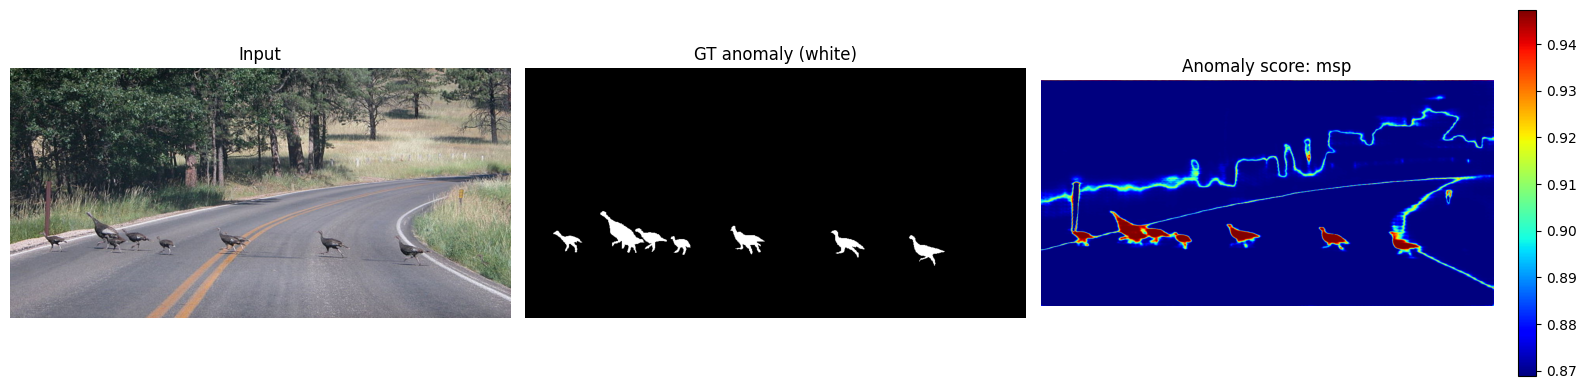

In [14]:
import matplotlib.pyplot as plt

def visualize(dataset_name, net, in_size, idx=0, method='msp', save=None):
    p = sorted(glob.glob(os.path.join(DATA_ROOT, dataset_name, 'images', '*')))[idx]
    img = Image.open(p).convert('RGB')
    x = Compose([Resize(in_size, Image.BILINEAR), ToTensor()])(img).unsqueeze(0).cuda()
    with torch.no_grad(), torch.autocast('cuda', dtype=torch.float16):
        ml, cl = net(x)
    m = F.interpolate(ml[-1].float(), size=OUT_HW, mode='bilinear', align_corners=False)
    L = torch.einsum('bqhw,bqc->bchw', m.sigmoid(), cl[-1].float().softmax(-1)[..., :-1])
    score = anomaly_score(L, method).cpu().numpy()
    g = load_gt(os.path.splitext(p.replace('/images/', '/labels_masks/'))[0] + '.png', dataset_name)
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    ax[0].imshow(img.resize((1024, 512)));  ax[0].set_title('Input')
    ax[1].imshow(g == 1, cmap='gray');      ax[1].set_title('GT anomaly (white)')
    im = ax[2].imshow(score, cmap='jet');   ax[2].set_title(f'Anomaly score: {method}')
    for a in ax: a.axis('off')
    plt.colorbar(im, ax=ax[2], fraction=0.046); plt.tight_layout()
    if save: plt.savefig(save, dpi=130, bbox_inches='tight'); print("saved", save)
    plt.show()

visualize('RoadAnomaly21', eomt_city, (1024, 1024), idx=0, method='msp')

## Download Cityscapes (for Steps 4 & 5)
Pull Cityscapes from Kaggle directly into Colab. Paste your Kaggle API token (`KGAT_...`) into the hidden prompt when asked.

In [15]:
import os, getpass
tok = getpass.getpass("Paste your Kaggle token (KGAT_...): ").strip()
os.environ['KAGGLE_API_TOKEN'] = tok
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
p = os.path.expanduser('~/.kaggle/access_token')
open(p, 'w').write(tok); os.chmod(p, 0o600)
!pip install -q --upgrade kaggle
!kaggle datasets download -d kavithak1388/cityscapes -p /content --unzip
!ls /content/Cityscape

Paste your Kaggle token (KGAT_...): ··········
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.5/128.5 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.2/229.2 kB 28.6 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/kavithak1388/cityscapes
License(s): unknown
100% 11.0G/11.0G [10:31<00:00, 18.8MB/s]

gtFine	leftImg8bit


## Step 4 — Closed-set comparison (COCO vs Cityscapes EoMT)
**Class mappings.** Cityscapes `gtFine` uses `labelId`s; we remap to the 19 `trainId`s. The COCO model outputs 133 classes; we map its output indices to Cityscapes `trainId`s for the **16 classes the two label spaces share** (pole, traffic sign and rider have no COCO equivalent and are excluded). Indices verified against the repo's `CLASS_MAPPING`.

In [16]:
CITY_LABELID2TRAIN = {7:0,8:1,11:2,12:3,13:4,17:5,19:6,20:7,21:8,22:9,23:10,
                      24:11,25:12,26:13,27:14,28:15,31:16,32:17,33:18}
CITY_NAMES = ['road','sidewalk','building','wall','fence','pole','tlight','tsign',
              'veg','terrain','sky','person','rider','car','truck','bus','train','moto','bike']

COCO2CITY = {100:0, 123:1, 129:2, 91:2, 101:2,        # road, sidewalk, building(+house,roof)
             109:3,110:3,111:3,112:3,131:3,           # walls -> wall
             117:4, 9:6, 116:8, 125:9,126:9, 119:10,  # fence, tlight, veg, terrain, sky
             0:11, 2:13, 7:14, 5:15, 6:16, 3:17, 1:18}# person,car,truck,bus,train,moto,bike
COMPARE_IDS = sorted(set(COCO2CITY.values()))         # the 16 shared classes KGAT_0f5a51507509fb53ce21eb6ad4d843da

**Semantic inference & mIoU.** Images are **letterboxed** (aspect-preserving pad) to the model's square input — squashing destroys wide objects like vehicles. `eval_miou` accumulates a 20-class confusion matrix (index 19 = COCO classes with no Cityscapes equivalent) and returns per-class IoU. The `.astype(int)` in the `bincount` avoids a uint8 overflow for class indices ≥ 13.

In [17]:
CITY_VAL_IMG = '/content/Cityscape/leftImg8bit/val'
CITY_VAL_GT  = '/content/Cityscape/gtFine/val'
EVAL_HW = (512, 1024)

def remap(arr, mapping, default=255):
    out = np.full_like(arr, default)
    for k, v in mapping.items(): out[arr == k] = v
    return out

def predict_semantic(net, img, in_size):
    S = in_size[0]; W0, H0 = img.size
    newW, newH = S, max(1, round(H0 * S / W0))          # keep aspect ratio
    im = img.resize((newW, newH), Image.BILINEAR)
    canvas = Image.new('RGB', (S, S)); top = (S - newH)//2
    canvas.paste(im, (0, top))                           # pad to square (no squash)
    x = ToTensor()(canvas).unsqueeze(0).cuda()
    with torch.no_grad(), torch.autocast('cuda', dtype=torch.float16):
        ml, cl = net(x)
    m = F.interpolate(ml[-1].float(), size=(S, S), mode='bilinear', align_corners=False)
    L = torch.einsum('bqhw,bqc->bchw', m.sigmoid(), cl[-1].float().softmax(-1)[..., :-1]).squeeze(0)
    L = L[:, top:top+newH, :]                            # crop the padding back off
    pred = L.argmax(0).byte().cpu().numpy()
    return np.array(Image.fromarray(pred).resize((EVAL_HW[1], EVAL_HW[0]), Image.NEAREST))

def eval_miou(net, in_size, coco=False, limit=None):
    paths = sorted(glob.glob(os.path.join(CITY_VAL_IMG, '*', '*_leftImg8bit.png')))[:limit]
    K = 20; conf = np.zeros((K, K), np.int64)
    for ip in paths:
        city = os.path.basename(os.path.dirname(ip)); base = os.path.basename(ip).replace('_leftImg8bit.png','')
        gt = remap(np.array(Image.open(os.path.join(CITY_VAL_GT, city, base+'_gtFine_labelIds.png'))
                            .resize((EVAL_HW[1], EVAL_HW[0]), Image.NEAREST)), CITY_LABELID2TRAIN)
        pred = predict_semantic(net, Image.open(ip).convert('RGB'), in_size)
        if coco: pred = remap(pred, COCO2CITY, default=19)
        v = gt != 255
        conf += np.bincount(gt[v].astype(int)*K + np.clip(pred[v],0,19).astype(int), minlength=K*K).reshape(K, K)
    iou = {}
    for c in range(19):
        tp=conf[c,c]; fp=conf[:,c].sum()-tp; fn=conf[c,:].sum()-tp; d=tp+fp+fn
        iou[c] = tp/d if d>0 else float('nan')
    return iou

Per-class IoU and mIoU on the 16 shared classes: Cityscapes EoMT vs COCO EoMT (full Cityscapes `val`).

In [18]:
iou_city = eval_miou(eomt_city, (1024,1024), coco=False, limit=None)
iou_coco = eval_miou(eomt_coco, (640,640),  coco=True,  limit=None)
df_miou = pd.DataFrame({
    'Cityscapes-EoMT': {CITY_NAMES[c]: round(100*iou_city[c],1) for c in COMPARE_IDS},
    'COCO-EoMT':       {CITY_NAMES[c]: round(100*iou_coco[c],1) for c in COMPARE_IDS}})
df_miou.loc['mIoU (16)'] = [round(np.nanmean([100*iou_city[c] for c in COMPARE_IDS]),1),
                            round(np.nanmean([100*iou_coco[c] for c in COMPARE_IDS]),1)]
df_miou.to_csv('/content/results_step4_miou.csv')
df_miou

,Cityscapes-EoMT,COCO-EoMT
road,98.1,93.4
sidewalk,84.8,61.3
building,92.2,83.1
wall,63.8,47.9
fence,61.8,39.2
tlight,65.9,45.8
veg,91.0,84.3
terrain,62.8,53.6
sky,93.9,87.0
person,78.1,60.0


ERFNet's mIoU on Cityscapes `val` (fills the mIoU column of the baseline table; ~72 over all 19 classes matches the published figure and validates the pipeline).

In [19]:
def eval_miou_erfnet(net, limit=None):
    paths = sorted(glob.glob(os.path.join(CITY_VAL_IMG,'*','*_leftImg8bit.png')))[:limit]
    K=20; conf=np.zeros((K,K),np.int64); tf=Compose([Resize((512,1024),Image.BILINEAR),ToTensor()])
    for ip in paths:
        city=os.path.basename(os.path.dirname(ip)); base=os.path.basename(ip).replace('_leftImg8bit.png','')
        gt=remap(np.array(Image.open(os.path.join(CITY_VAL_GT,city,base+'_gtFine_labelIds.png'))
                          .resize((EVAL_HW[1],EVAL_HW[0]),Image.NEAREST)), CITY_LABELID2TRAIN)
        x=tf(Image.open(ip).convert('RGB')).unsqueeze(0).cuda()
        with torch.no_grad(): logits=net(x)
        pred=F.interpolate(logits.float(),size=EVAL_HW,mode='bilinear',align_corners=False).squeeze(0)[:19].argmax(0).cpu().numpy()
        v=gt!=255
        conf+=np.bincount(gt[v].astype(int)*K+pred[v].astype(int),minlength=K*K).reshape(K,K)
    iou={}
    for c in range(19):
        tp=conf[c,c];fp=conf[:,c].sum()-tp;fn=conf[c,:].sum()-tp;d=tp+fp+fn
        iou[c]=tp/d if d>0 else float('nan')
    return iou

iou_erf = eval_miou_erfnet(model, limit=None)
print("ERFNet mIoU (16 shared):", round(np.nanmean([100*iou_erf[c] for c in COMPARE_IDS]),1))
print("ERFNet mIoU (all 19):  ", round(np.nanmean([100*iou_erf[c] for c in range(19)]),1))

ERFNet mIoU (16 shared): 74.0
ERFNet mIoU (all 19):   72.2


## Step 5 — Fine-tuning the COCO model on Cityscapes
Reload the COCO model, **freeze everything**, and replace the classification head with a fresh 19-class head — only this head (15k params) is trained.

In [20]:
import torch.nn as nn
eomt_ft, _ = load_eomt(CFG_COCO, CKPT_COCO, num_classes=133, img_size=(640,640))   # COCO features
dim = eomt_ft.encoder.backbone.embed_dim
eomt_ft.class_head = nn.Linear(dim, 20).cuda()        # new head: 19 classes + no-object
for p in eomt_ft.parameters(): p.requires_grad = False
for p in eomt_ft.class_head.parameters(): p.requires_grad = True
eomt_ft.eval()
print("trainable params:", sum(p.numel() for p in eomt_ft.parameters() if p.requires_grad))

missing=0  unexpected=0
trainable params: 15380


Cityscapes training dataset (letterboxed images + `trainId` labels), on a 1000-image subset for speed.

In [21]:
from torch.utils.data import Dataset, DataLoader
TRAIN = sorted(glob.glob('/content/Cityscape/leftImg8bit/train/*/*_leftImg8bit.png'))[:1000]
S, OUT = 640, 160
class CityTrain(Dataset):
    def __len__(self): return len(TRAIN)
    def __getitem__(self, i):
        ip = TRAIN[i]; img = Image.open(ip).convert('RGB'); W0,H0 = img.size
        newH = max(1, round(H0*S/W0)); top = (S-newH)//2
        canvas = Image.new('RGB',(S,S)); canvas.paste(img.resize((S,newH),Image.BILINEAR),(0,top))
        x = ToTensor()(canvas)
        city = os.path.basename(os.path.dirname(ip)); base = os.path.basename(ip).replace('_leftImg8bit.png','')
        g = remap(np.array(Image.open(f'/content/Cityscape/gtFine/train/{city}/{base}_gtFine_labelIds.png')),
                  CITY_LABELID2TRAIN)
        gc = Image.new('L',(S,S),255); gc.paste(Image.fromarray(g.astype(np.uint8)).resize((S,newH),Image.NEAREST),(0,top))
        return x, torch.from_numpy(np.array(gc.resize((OUT,OUT),Image.NEAREST)).astype(np.int64))
loader = DataLoader(CityTrain(), batch_size=4, shuffle=True, num_workers=2, drop_last=True)
print("batches/epoch:", len(loader))

batches/epoch: 250


Train the head with a per-pixel cross-entropy on the semantic score map (frozen backbone + masks). AMP for speed.

In [22]:
opt = torch.optim.AdamW(eomt_ft.class_head.parameters(), lr=1e-3)
scaler = torch.amp.GradScaler('cuda')
for epoch in range(2):
    running = 0
    for it,(x,gt) in enumerate(loader):
        x,gt = x.cuda(), gt.cuda()
        with torch.autocast('cuda', dtype=torch.float16):
            ml,cl = eomt_ft(x)
        mask = F.interpolate(ml[-1].float(), size=(OUT,OUT), mode='bilinear', align_corners=False)
        P = torch.einsum('bqhw,bqc->bchw', mask.sigmoid(), cl[-1].float().softmax(-1))  # (B,20,h,w)
        P19 = P[:, :19]; P19 = P19 / (P19.sum(1, keepdim=True) + 1e-6)
        loss = F.nll_loss(torch.log(P19 + 1e-6), gt, ignore_index=255)
        opt.zero_grad(); scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        running += loss.item()
        if it % 50 == 0: print(f"epoch {epoch} it {it} loss {loss.item():.3f}")
    print(f"== epoch {epoch} avg loss {running/len(loader):.3f}")

epoch 0 it 0 loss 2.773
epoch 0 it 50 loss 0.288
epoch 0 it 100 loss 0.350
epoch 0 it 150 loss 0.283
epoch 0 it 200 loss 0.250
== epoch 0 avg loss 0.375
epoch 1 it 0 loss 0.184
epoch 1 it 50 loss 0.271
epoch 1 it 100 loss 0.305
epoch 1 it 150 loss 0.227
epoch 1 it 200 loss 0.239
== epoch 1 avg loss 0.255


Save the fine-tuned head and report the 3-way mIoU comparison (Cityscapes vs COCO vs fine-tuned).

In [23]:
torch.save(eomt_ft.class_head.state_dict(), '/content/eomt_ft_head.pth')
iou_ft = eval_miou(eomt_ft, (640,640), coco=False, limit=None)
df3 = pd.DataFrame({
    'Cityscapes-EoMT': {CITY_NAMES[c]: round(100*iou_city[c],1) for c in COMPARE_IDS},
    'COCO-EoMT':       {CITY_NAMES[c]: round(100*iou_coco[c],1) for c in COMPARE_IDS},
    'COCO->FT':        {CITY_NAMES[c]: round(100*iou_ft[c],1)   for c in COMPARE_IDS}})
for col, iou in [('Cityscapes-EoMT',iou_city),('COCO-EoMT',iou_coco),('COCO->FT',iou_ft)]:
    df3.loc['mIoU (16)', col] = round(np.nanmean([100*iou[c] for c in COMPARE_IDS]), 1)
df3.to_csv('/content/results_step4_finetuned.csv')
df3

,Cityscapes-EoMT,COCO-EoMT,COCO->FT
road,98.1,93.4,96.3
sidewalk,84.8,61.3,72.3
building,92.2,83.1,86.1
wall,63.8,47.9,36.0
fence,61.8,39.2,44.5
tlight,65.9,45.8,47.2
veg,91.0,84.3,85.5
terrain,62.8,53.6,56.7
sky,93.9,87.0,89.4
person,78.1,60.0,65.3


Anomaly table for the **fine-tuned** EoMT checkpoint (the third checkpoint of Step 8).

In [24]:
results_eomt_ft = {}
for ds in DATASETS:
    results_eomt_ft[ds] = evaluate_all_eomt(ds, eomt_ft, in_size=(640,640))
    print("done:", ds)
rows = []
for m in EOMT_METHODS:
    row = {'Method': m}
    for ds in DATASETS:
        a, f = results_eomt_ft[ds][m]
        row[f'{COLS[ds]} AuPRC'] = round(a, 2); row[f'{COLS[ds]} FPR95'] = round(f, 2)
    rows.append(row)
df_eomt_ft = pd.DataFrame(rows).set_index('Method')
df_eomt_ft.to_csv('/content/results_eomt_finetuned.csv')
df_eomt_ft

done: RoadAnomaly21
done: RoadObsticle21
done: FS_LostFound_full
done: fs_static
done: RoadAnomaly


,RA-21 AuPRC,RA-21 FPR95,RO-21 AuPRC,RO-21 FPR95,FS L&F AuPRC,FS L&F FPR95,FS Static AuPRC,FS Static FPR95,Road Anomaly AuPRC,Road Anomaly FPR95
Method,,,,,,,,,,
msp,44.08,31.81,55.83,99.98,0.31,87.97,29.15,54.81,38.16,90.86
maxlogit,41.26,33.19,51.11,99.99,0.29,89.00,25.66,55.04,35.35,92.07
maxentropy,38.79,34.05,49.50,99.99,0.29,88.56,22.66,54.82,34.15,92.77
rba,16.01,88.99,2.90,100.00,0.19,98.80,4.31,79.69,18.03,97.31


## Report figures
Generate and save the qualitative figures for the report. Run this after all three EoMT checkpoints are loaded and Cityscapes is downloaded. Saved PNGs land in `/content/`.

One qualitative panel (input / GT / anomaly heatmap) per benchmark.

saved /content/qual_RoadAnomaly21.png


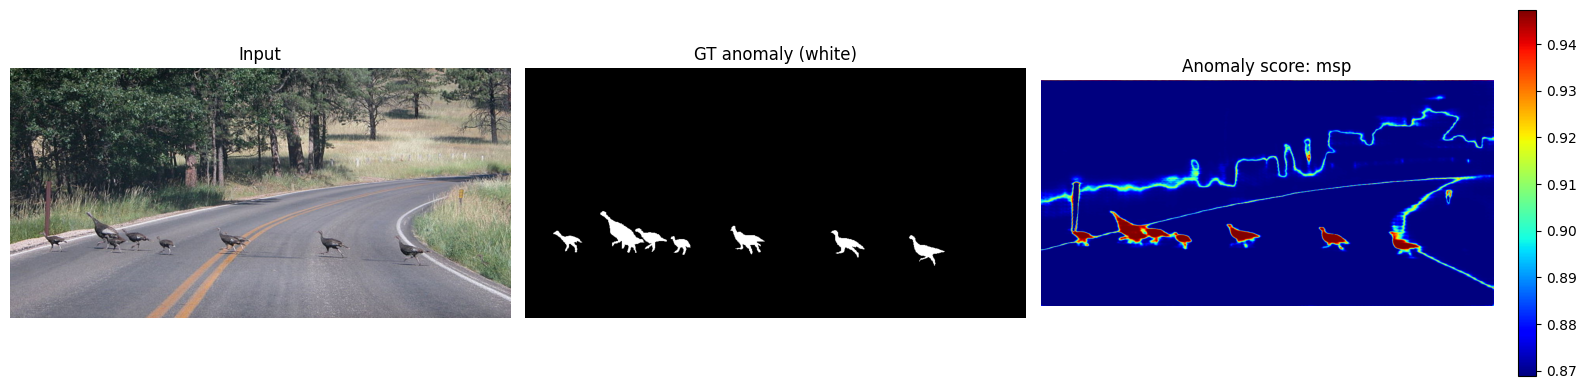

saved /content/qual_RoadObsticle21.png


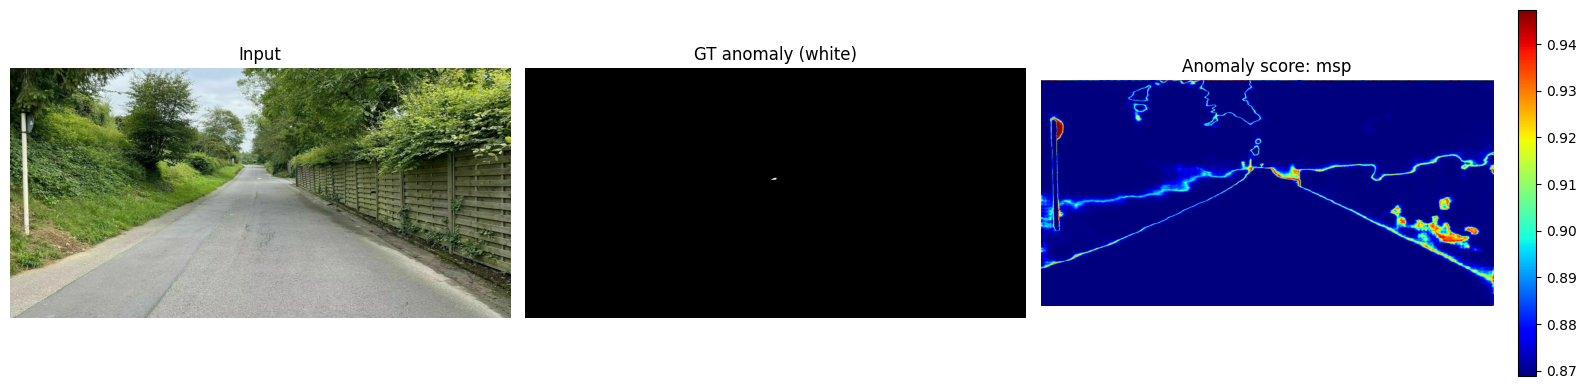

saved /content/qual_FS_LostFound_full.png


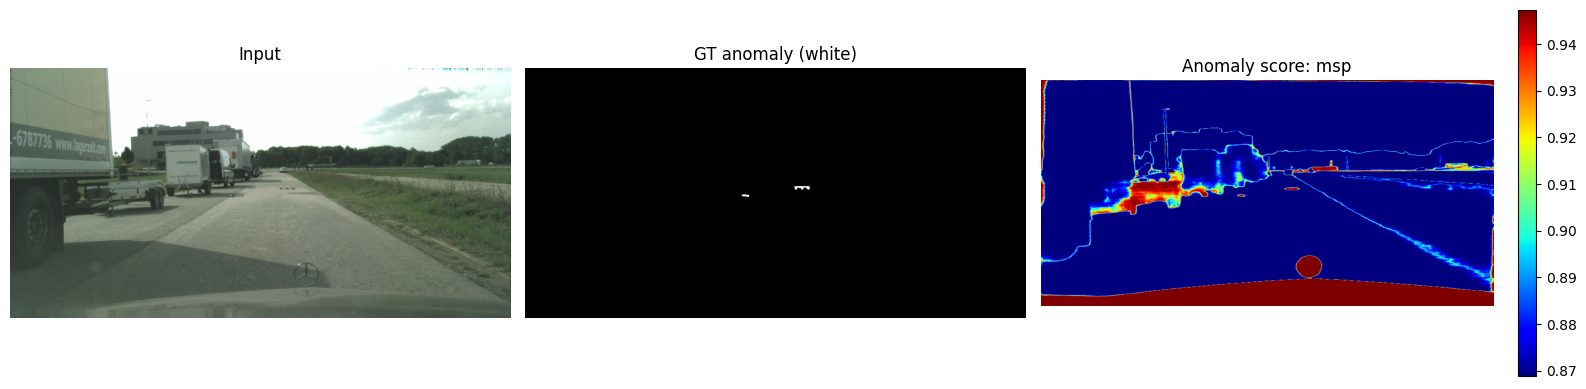

saved /content/qual_fs_static.png


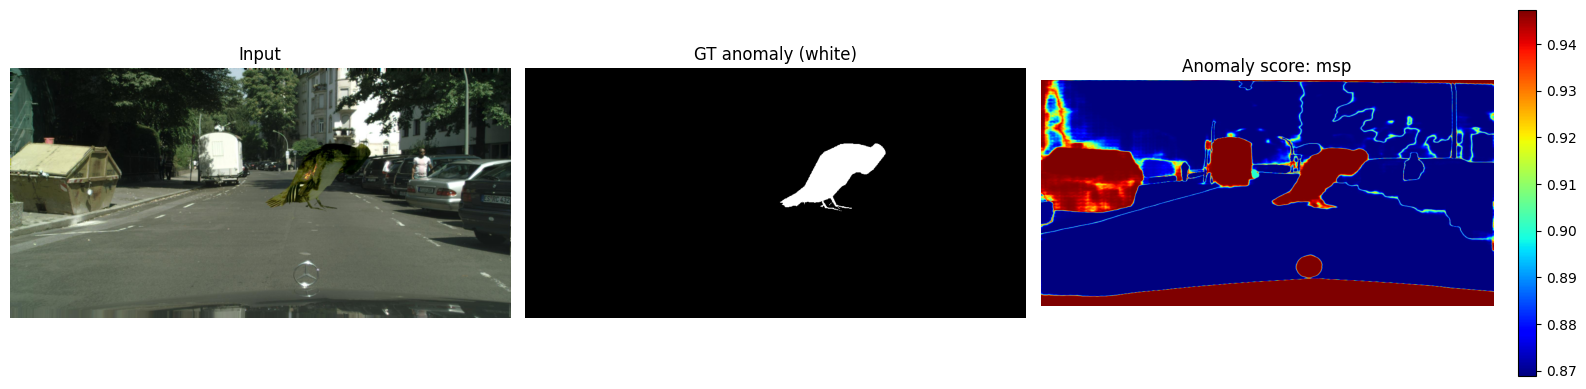

saved /content/qual_RoadAnomaly.png


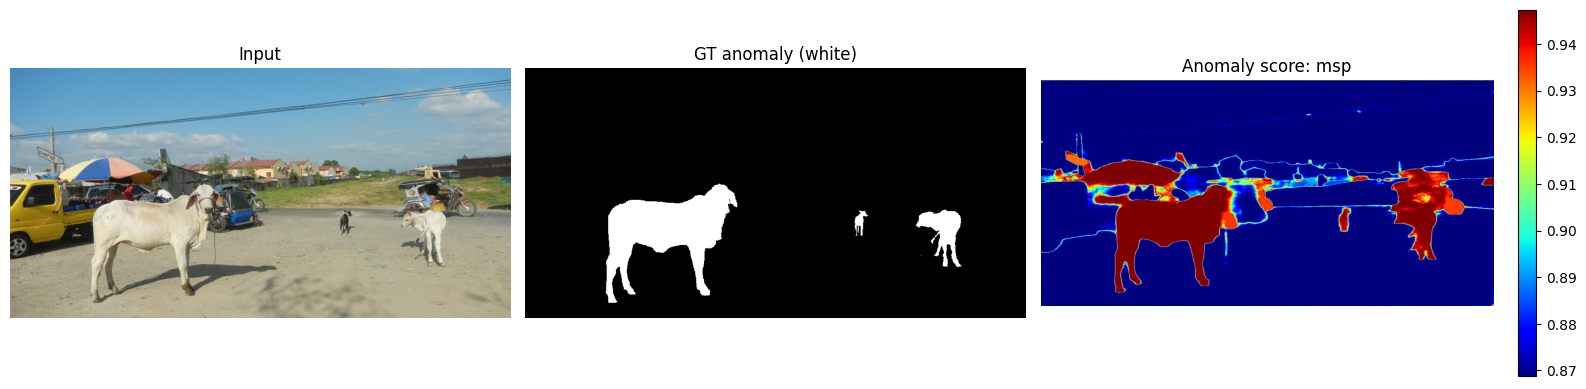

In [25]:
for ds in ['RoadAnomaly21', 'RoadObsticle21', 'FS_LostFound_full', 'fs_static', 'RoadAnomaly']:
    visualize(ds, eomt_city, (1024, 1024), idx=0, method='msp', save=f'/content/qual_{ds}.png')

Model comparison on one image: anomaly heatmaps from the Cityscapes, COCO and fine-tuned EoMT side by side (shows the fine-tuning improvement qualitatively).

saved /content/compare_models.png


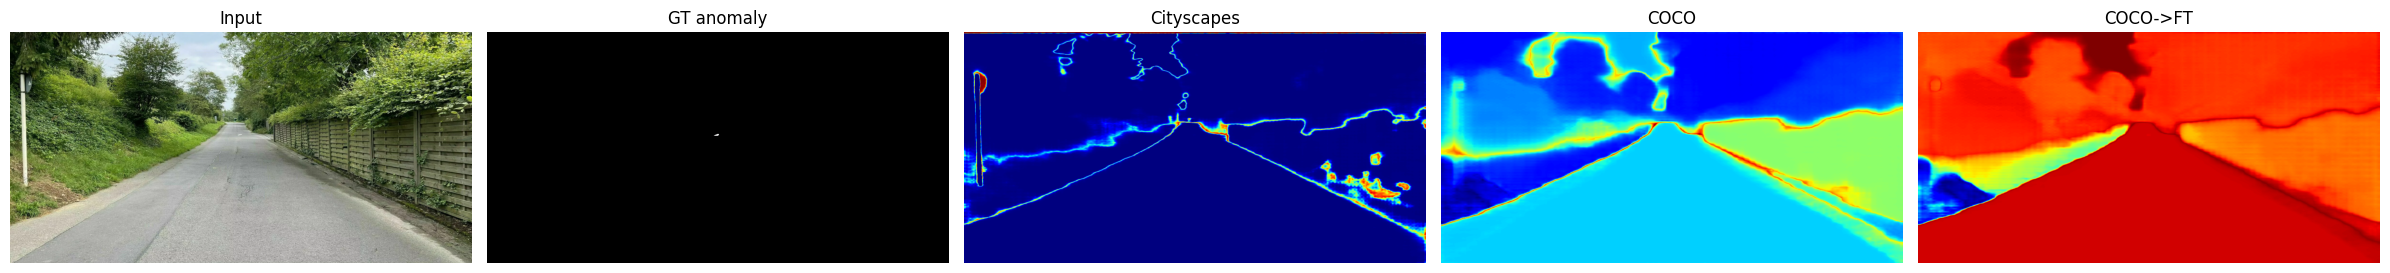

In [26]:
def compare_models(dataset_name, idx=0, method='msp', save=None):
    p = sorted(glob.glob(os.path.join(DATA_ROOT, dataset_name, 'images', '*')))[idx]
    img = Image.open(p).convert('RGB')
    g = load_gt(os.path.splitext(p.replace('/images/', '/labels_masks/'))[0] + '.png', dataset_name)
    nets = [('Cityscapes', eomt_city, (1024,1024)), ('COCO', eomt_coco, (640,640)), ('COCO->FT', eomt_ft, (640,640))]
    fig, ax = plt.subplots(1, 5, figsize=(24, 4))
    ax[0].imshow(img.resize((1024,512))); ax[0].set_title('Input')
    ax[1].imshow(g==1, cmap='gray');      ax[1].set_title('GT anomaly')
    for k,(name,net,insz) in enumerate(nets):
        x = Compose([Resize(insz, Image.BILINEAR), ToTensor()])(img).unsqueeze(0).cuda()
        with torch.no_grad(), torch.autocast('cuda', dtype=torch.float16):
            ml, cl = net(x)
        m = F.interpolate(ml[-1].float(), size=OUT_HW, mode='bilinear', align_corners=False)
        L = torch.einsum('bqhw,bqc->bchw', m.sigmoid(), cl[-1].float().softmax(-1)[..., :-1])
        s = anomaly_score(L, method).cpu().numpy()
        ax[k+2].imshow(s, cmap='jet'); ax[k+2].set_title(name)
    for a in ax: a.axis('off')
    plt.tight_layout()
    if save: plt.savefig(save, dpi=130, bbox_inches='tight'); print("saved", save)
    plt.show()

compare_models('RoadObsticle21', idx=0, method='msp', save='/content/compare_models.png')

**Step 4 — qualitative panoptic comparison.** Each pixel is coloured by the query that owns it (highest `sigmoid(mask) x class-confidence`), so distinct instances appear as distinct colours. The COCO model (panoptic head) separates instances; the Cityscapes semantic checkpoint, never trained with instance supervision, produces coarser regions. Simplified (winning-query) panoptic view; colours are query IDs, not fixed class colours.

saved /content/panoptic_compare.png


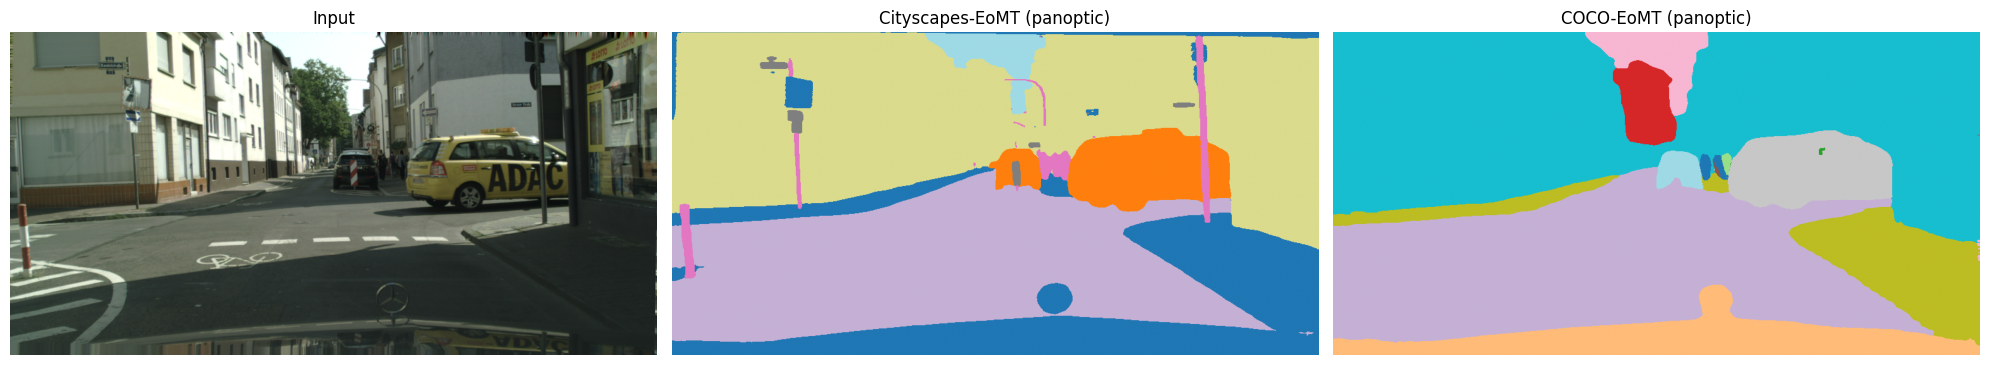

In [27]:
def panoptic_map(net, img, in_size):
    x = Compose([Resize(in_size, Image.BILINEAR), ToTensor()])(img).unsqueeze(0).cuda()
    with torch.no_grad(), torch.autocast('cuda', dtype=torch.float16):
        ml, cl = net(x)
    H, W = 512, 1024
    mask = F.interpolate(ml[-1].float(), size=(H, W), mode='bilinear', align_corners=False).sigmoid().squeeze(0)
    qconf = cl[-1].float().softmax(-1).squeeze(0)[:, :-1].max(-1).values
    weighted = mask * qconf[:, None, None]
    winner = weighted.argmax(0)
    winner[weighted.max(0).values < 0.1] = -1
    return winner.cpu().numpy()

def show_panoptic(img_path, save=None):
    img = Image.open(img_path).convert('RGB')
    pc  = panoptic_map(eomt_city, img, (1024, 1024))
    pco = panoptic_map(eomt_coco, img, (640, 640))
    fig, ax = plt.subplots(1, 3, figsize=(20, 4))
    ax[0].imshow(img.resize((1024, 512)));   ax[0].set_title('Input')
    ax[1].imshow(pc,  cmap='tab20');          ax[1].set_title('Cityscapes-EoMT (panoptic)')
    ax[2].imshow(pco, cmap='tab20');          ax[2].set_title('COCO-EoMT (panoptic)')
    for a in ax: a.axis('off')
    plt.tight_layout()
    if save: plt.savefig(save, dpi=130, bbox_inches='tight'); print("saved", save)
    plt.show()

ip = sorted(glob.glob('/content/Cityscape/leftImg8bit/val/*/*_leftImg8bit.png'))[0]
show_panoptic(ip, save='/content/panoptic_compare.png')